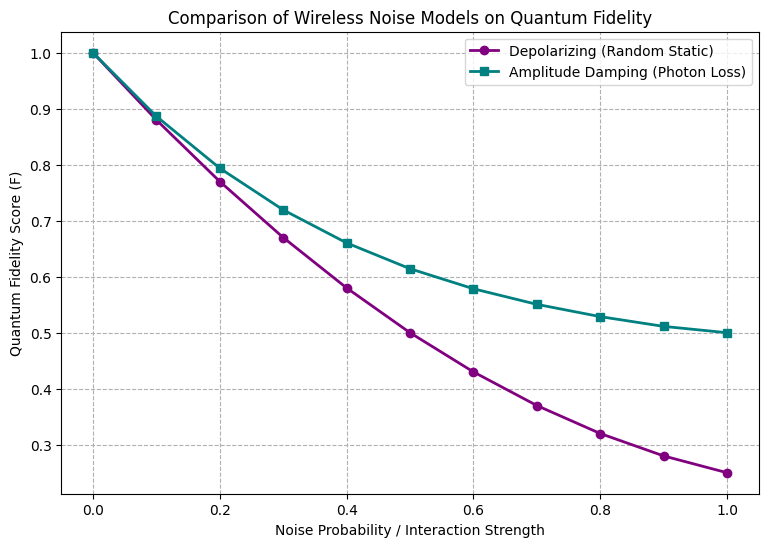

In [ ]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, amplitude_damping_error
from qiskit.quantum_info import state_fidelity
import matplotlib.pyplot as plt

# 1. Build Ideal Circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

simulator = AerSimulator(method='density_matrix')
compiled_circuit = transpile(qc, simulator)
compiled_circuit.save_density_matrix()
matrix_ideal = simulator.run(compiled_circuit).result().data()['density_matrix']

noise_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
fid_depolarizing = []
fid_damping = []


for noise in noise_levels:
    
    # model 1: Depolarizing Noise (Static)
    noise_depol = NoiseModel()
    noise_depol.add_all_qubit_quantum_error(depolarizing_error(noise, 1), ['h'])
    noise_depol.add_all_qubit_quantum_error(depolarizing_error(noise, 2), ['cx'])
    
    sim_depol = AerSimulator(noise_model=noise_depol, method='density_matrix')
    mat_depol = sim_depol.run(compiled_circuit).result().data()['density_matrix']
    fid_depolarizing.append(state_fidelity(matrix_ideal, mat_depol))
    
    # model 2: Amplitude Damping (Energy Loss)
    noise_damp = NoiseModel()
    # Amplitude damping is a 1-qubit effect. To apply it to a 2-qubit CX gate, we tensor it.
    error_damp_1 = amplitude_damping_error(noise)
    error_damp_2 = error_damp_1.tensor(error_damp_1) 
    
    noise_damp.add_all_qubit_quantum_error(error_damp_1, ['h'])
    noise_damp.add_all_qubit_quantum_error(error_damp_2, ['cx'])
    
    sim_damp = AerSimulator(noise_model=noise_damp, method='density_matrix')
    mat_damp = sim_damp.run(compiled_circuit).result().data()['density_matrix']
    fid_damping.append(state_fidelity(matrix_ideal, mat_damp))

# 3. Draw the Comparison Graph
plt.figure(figsize=(9, 6))
plt.plot(noise_levels, fid_depolarizing, marker='o', color='purple', label='Depolarizing (Random Static)', linewidth=2)
plt.plot(noise_levels, fid_damping, marker='s', color='teal', label='Amplitude Damping (Photon Loss)', linewidth=2)
plt.title('Comparison of Wireless Noise Models on Quantum Fidelity')
plt.xlabel('Noise Probability / Interaction Strength')
plt.ylabel('Quantum Fidelity Score (F)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()